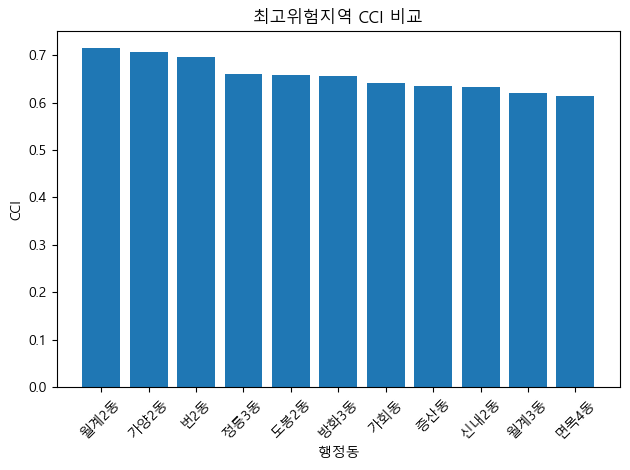

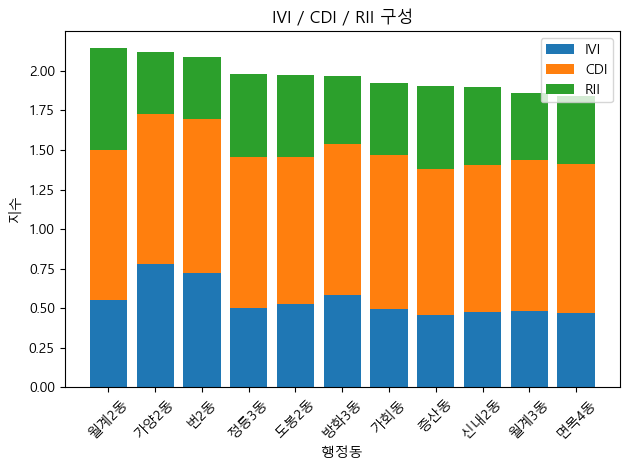

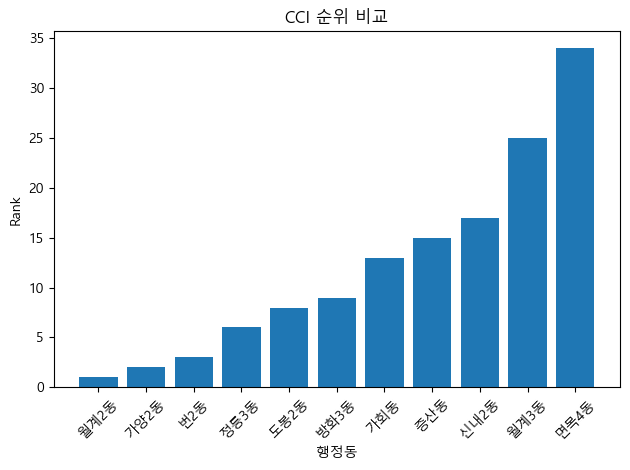

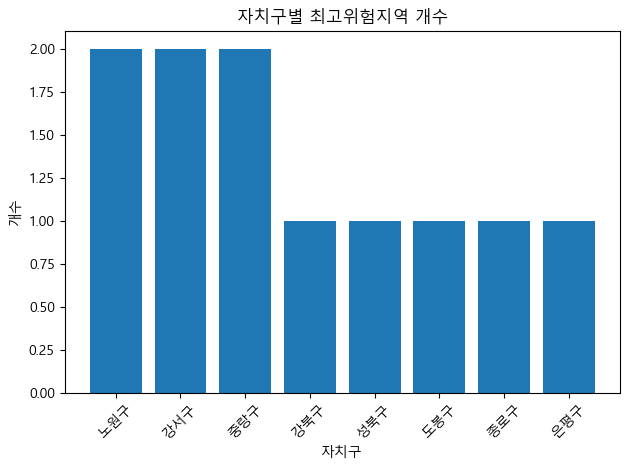

완료: 그래프 4개 생성됨


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 (윈도우)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv('../data/output/top_risk_dongs_2021.csv')
#이거 위에 자꾸 안됨... 파일 자체가 없어서 이러는 것 같은데 파일 추가가 안됨.
#왜인지 모르겠지만 현재 내 로컬 거기서 데이터 추가했더니 성공! 문제 생길시 경로만 수정하면 됨.
# -----------------------------
# 1. CCI bar chart
# -----------------------------
plt.figure()
df_sorted = df.sort_values('CCI', ascending=False)

plt.bar(df_sorted['행정동명'], df_sorted['CCI'])
plt.xticks(rotation=45)
plt.title('최고위험지역 CCI 비교')
plt.xlabel('행정동')
plt.ylabel('CCI')

plt.tight_layout()
plt.savefig('../outputs/cci_bar_chart.png')
plt.show()

# -----------------------------
# 2. stacked bar chart
# -----------------------------
plt.figure()

x = range(len(df))

plt.bar(x, df['IVI'], label='IVI')
plt.bar(x, df['CDI'], bottom=df['IVI'], label='CDI')
plt.bar(x, df['RII'], bottom=df['IVI'] + df['CDI'], label='RII')

plt.xticks(x, df['행정동명'], rotation=45)
plt.title('IVI / CDI / RII 구성')
plt.xlabel('행정동')
plt.ylabel('지수')
plt.legend()

plt.tight_layout()
plt.savefig('../outputs/stacked_bar_chart.png')
plt.show()

# -----------------------------
# 3. CCI rank chart
# -----------------------------
plt.figure()

plt.bar(df['행정동명'], df['CCI_rank'])
plt.xticks(rotation=45)
plt.title('CCI 순위 비교')
plt.xlabel('행정동')
plt.ylabel('Rank')

plt.tight_layout()
plt.savefig('../outputs/cci_rank_chart.png')
plt.show()

# -----------------------------
# 4. 자치구별 개수
# -----------------------------
plt.figure()

gu_counts = df['자치구명'].value_counts()

plt.bar(gu_counts.index, gu_counts.values)
plt.xticks(rotation=45)
plt.title('자치구별 최고위험지역 개수')
plt.xlabel('자치구')
plt.ylabel('개수')

plt.tight_layout()
plt.savefig('../outputs/gu_count_chart.png')
plt.show()

print("완료: 그래프 4개 생성됨")

[복합위기 최고위험지역 정의]

복합위기 최고위험지역(triple_high_flag)은 사회적 고립 취약도(IVI), 생활 인프라 부족도(CDI), 강우·수해 취약도(RII) 세 지수가 모두 상위 30%에 해당하는 행정동을 의미한다. 이는 단일 위험요인이 아닌, 서로 다른 성격의 취약성이 동시에 중첩된 지역으로서 복합적인 위험 구조를 갖는다.

[지도 해석]

triple_high_map_2021을 통해 확인한 결과, 복합위기 최고위험지역은 서울 전역에 완전히 균등하게 분포하기보다는 일부 지역에 상대적으로 집중되면서도, 특정 지역에서는 산발적으로 나타나는 패턴을 보인다. 특히 외곽 주거지역이나 노후 주거지 중심으로 분포하는 경향이 관찰되며, 이는 생활 인프라 접근성과 자연재해 취약성이 동시에 작용하는 공간적 특성과 관련이 있다.

지도에서 빨간색으로 표시된 지역은 단순히 하나의 지수가 높은 지역이 아니라, IVI·CDI·RII 세 지수가 모두 상위 30%에 해당하는 교집합 지역이다. 따라서 이들 지역은 단일 정책으로 대응하기 어려운 복합위기 지역으로 해석할 수 있다.

지역별 해석
월계2동(노원구)은 RII가 매우 높고 CDI도 매우 높은 수준이며 IVI 역시 상위권에 포함되어 수해·인프라·사회 취약성이 모두 중첩된 대표적인 최고위험지역이다.
가양2동(강서구)은 IVI와 CDI가 매우 높은 반면 RII는 상대적으로 낮지만 여전히 상위 30%에 포함되어 복합 취약성이 유지되는 지역이다.
번2동(강북구)은 CDI가 매우 높고 IVI 또한 높은 수준이며, RII까지 포함되어 전반적인 복합위기 수준이 높은 지역이다.
정릉3동(성북구)은 CDI가 매우 높은 가운데 RII도 높은 편이며 IVI까지 포함되어 균형적인 복합 취약성을 보인다.
도봉2동(도봉구)은 세 지수가 모두 고르게 높은 수준으로 나타나 전반적인 취약성이 균형적으로 분포된 지역이다.
방화3동(강서구)은 CDI가 매우 높고 IVI와 RII가 함께 나타나 생활 인프라와 재난 취약성이 결합된 지역이다.
가회동(종로구)은 CDI가 매우 높은 동시에 IVI와 RII도 상위권에 포함되어 도심 내 복합 취약지역으로 해석된다.
증산동(은평구)은 CDI와 RII가 높은 편이며 IVI도 포함되어 자연재해와 생활 취약성이 동시에 나타난다.
신내2동(중랑구)은 세 지수가 모두 중상위 수준으로 고르게 나타나 복합위기 구조가 형성된 지역이다.
월계3동(노원구)은 CDI가 매우 높고 IVI와 RII가 함께 나타나 생활 인프라 중심의 취약성이 두드러진다.
면목4동(중랑구)은 CDI가 높은 가운데 IVI와 RII도 상위 수준으로 나타나 복합적인 취약 구조를 보인다.

[CCI 순위와의 차이]

분석 결과, triple_high 지역은 단순히 CCI(종합위기지수) 상위 지역과 완전히 일치하지 않는다. 이는 CCI가 세 지수를 합산한 값인 반면, triple_high는 세 지수가 모두 일정 수준 이상이어야 하는 “교집합 조건”이기 때문이다.

따라서 일부 지역은 CCI가 높더라도 특정 지수가 낮아 triple_high에 포함되지 않을 수 있으며, 반대로 CCI 순위가 상대적으로 낮더라도 세 지수가 모두 상위 30%에 해당하면 triple_high 지역으로 분류된다.

이러한 차이는 단순 합산 기반 평가와 복합 취약성 기반 평가 간의 구조적 차이를 보여준다.

[정책 우선순위]

triple_high 지역은 복합 취약성이 중첩된 지역으로, 정책적 개입의 우선순위가 가장 높은 지역으로 해석할 수 있다. 단일 위험 대응이 아닌 다차원적 정책 패키지가 필요하다.

정책 제안

고령 1인가구 대상 정기 안부 확인 시스템 구축
강우 예보 시 취약계층 대상 사전 연락 체계 마련
침수 취약지역 대피 지원 및 이동 보조
생활 필수품(식료품, 의약품) 배송 지원
약국 및 의료시설 접근성 개선
지역 돌봄센터 및 임시 대피 거점 연계 강화

[추가 시각화 제안]

분석 결과를 보다 효과적으로 전달하기 위해 다음과 같은 시각화를 추가로 활용할 수 있다.

최고위험지역 11개 행정동 CCI bar chart
IVI/CDI/RII stacked bar chart (취약성 구성 비교)
CCI 순위 비교 그래프
자치구별 최고위험지역 개수 그래프
최고위험지역 라벨링 지도
최고위험지역 주변 risk_type 분포 지도

[보고서용 핵심 문장]

복합위기 최고위험지역은 사회적 고립, 생활 인프라 부족, 수해 취약성이 동시에 높은 지역으로 정의되며, 단일 위험이 아닌 다차원적 취약성이 중첩된 공간적 특성을 갖는다. 2021년 분석 결과, 이러한 지역은 서울 내 일부 권역에 집중되면서도 산발적으로 분포하는 양상을 보였다.

이들 지역은 단순 종합지수(CCI) 상위 지역과는 차이를 보이며, 세 지수의 교집합 조건을 만족하는 구조적 취약지역이라는 점에서 정책적 중요성이 크다. 따라서 triple_high 지역은 최우선 정책 개입 대상지로 설정하고, 돌봄·재난·생활지원이 결합된 통합적 대응 전략이 필요하다.